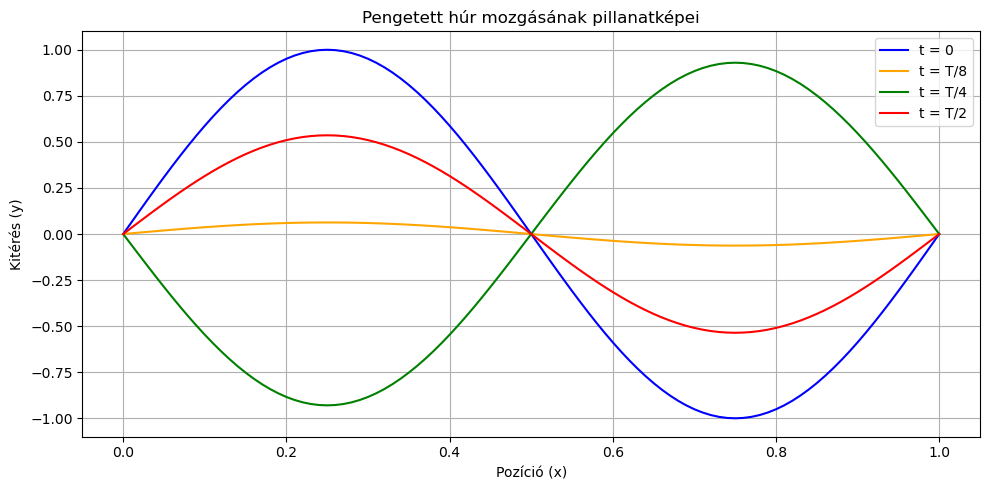

GIF animáció sikeresen elmentve (hur_animacio.gif)!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Minden sor egy időlépés, minden oszlop egy x koordináta
data = np.loadtxt("datas/string_normal.data")
N_frames = data.shape[0]
N_points = data.shape[1]

L = 1.0
x = np.linspace(0, L, N_points)

fig_static, ax_static = plt.subplots(figsize = (10, 5))

frames_to_plot = [0, int(N_frames/8), int(N_frames/4), int(N_frames/2)]
colors = ["blue", "orange", "green", "red"]
labels = ["t = 0", "t = T/8", "t = T/4", "t = T/2"]

for idx, f_idx in enumerate(frames_to_plot):
    ax_static.plot(x, data[f_idx, :], color = colors[idx], label = labels[idx])

ax_static.set_title("Pengetett húr mozgásának pillanatképei")
ax_static.set_xlabel("Pozíció (x)")
ax_static.set_ylabel("Kitérés (y)")
ax_static.grid(True)
ax_static.legend()

plt.tight_layout()
plt.savefig("hur_pillanatkepek.pdf")
plt.show()

fig_anim, ax_anim = plt.subplots(figsize = (8, 4))
ax_anim.set_xlim(0, L)
ax_anim.set_ylim(-1.5, 1.5)
ax_anim.set_title("Húr rezgésének animációja")
ax_anim.set_xlabel("Pozíció (x)")
ax_anim.set_ylabel("Kitérés (y)")
ax_anim.grid(True)

line, = ax_anim.plot([], [], color = "blue", lw = 2)

def init():
    line.set_data([], [])
    return line,

def animate(i):
    line.set_data(x, data[i, :])
    return line,

anim = animation.FuncAnimation(fig_anim, animate, init_func = init,
                               frames = N_frames, interval = 20, blit = True)

anim.save("2.gif", writer = "pillow", fps = 30)
print("GIF animáció sikeresen elmentve (hur_animacio.gif)!")
plt.close(fig_anim) # Nem jelenítjük meg duplán

In [ ]:
import numpy as np

data = np.loadtxt("datas/string_plucked.data")
N_points = data.shape[1]

L = 1.0
T_tension = 10.0
rho = 0.01
c_elmeleti = np.sqrt(T_tension / rho)

dx = L / (N_points - 1)
dt = 1.0 * (dx / c_elmeleti)
skip_frames = 5

x = np.linspace(0, L, N_points)

y_start = data[0, :]
peak_start_idx = np.argmax(y_start)
x_start = x[peak_start_idx]

frame_idx = 8
t_end = (frame_idx * skip_frames + 1) * dt
y_end = data[frame_idx, :]

search_region = x > (x_start + 0.05) 
peak_end_idx_relative = np.argmax(y_end[search_region])
x_end = x[search_region][peak_end_idx_relative]

v_numerikus = (x_end - x_start) / t_end

print(f" Elméleti (fizikai) sebesség: {c_elmeleti:.4f} m/s")
print(f" Mért (szimulált) sebesség:   {v_numerikus:.4f} m/s")
print(f" Hiba:                        {abs(c_elmeleti - v_numerikus):.6f} m/s")

 Elméleti (fizikai) sebesség: 31.6228 m/s
 Mért (szimulált) sebesség:   31.6228 m/s
 Hiba:                        0.000000 m/s


<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
C:\Users\krucs\AppData\Local\Temp\ipykernel_10364\3013075567.py:35: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Térbeli lépésköz, $\Delta x$ (m)', fontsize=12)
C:\Users\krucs\AppData\Local\Temp\ipykernel_10364\3013075567.py:36: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Időlépés, $\Delta t$ (s)', fontsize=12)


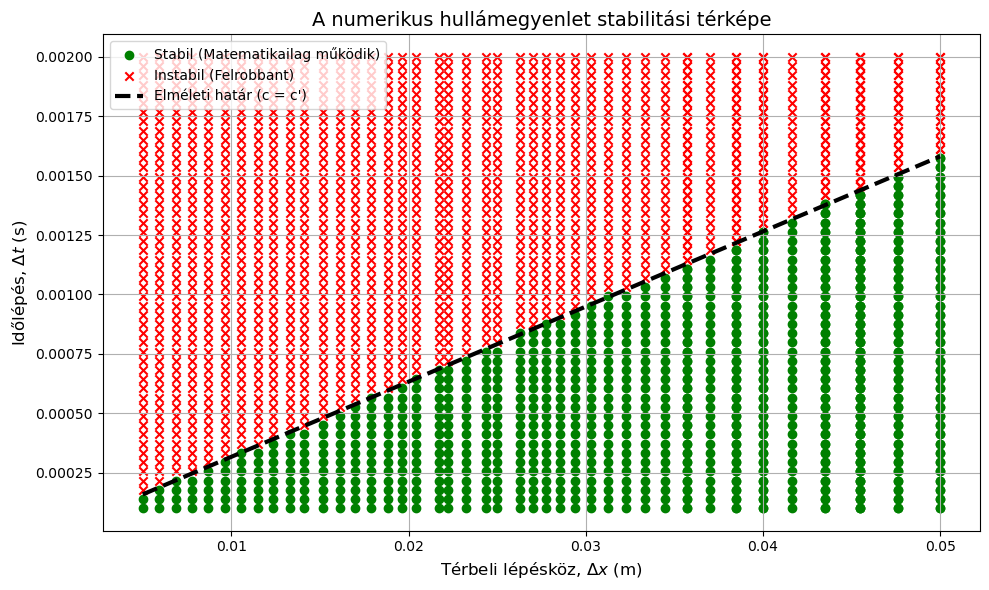

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("datas/stability_map.data")
dx = data[:, 0]
dt = data[:, 1]
stable = data[:, 2]

c = np.sqrt(10.0 / 0.01)

dx_stable = dx[stable == 1]
dt_stable = dt[stable == 1]

dx_unstable = dx[stable == 0]
dt_unstable = dt[stable == 0]

plt.figure(figsize=(10, 6))

# Zöld pontok: Stabil (Courant <= 1)
plt.scatter(dx_stable, dt_stable, color = "green", label = "Stabil (Matematikailag működik)")

# Piros pontok: Instabil (Courant > 1)
plt.scatter(dx_unstable, dt_unstable, color = "red", marker = "x", label = "Instabil (Felrobbant)")

# Az elméleti határvonal: dt = dx / c  (azaz c = c")
dx_line = np.linspace(min(dx), max(dx), 100)
dt_line = dx_line / c
plt.plot(dx_line, dt_line, color = "black", linewidth = 3, linestyle = "--", label = "Elméleti határ (c = c\")")

plt.title("A numerikus hullámegyenlet stabilitási térképe", fontsize = 14)
plt.xlabel("Térbeli lépésköz, $\Delta x$ (m)", fontsize = 12)
plt.ylabel("Időlépés, $\Delta t$ (s)", fontsize = 12)
plt.grid(True)
plt.legend(loc = "upper left")

plt.tight_layout()
plt.savefig("stabilitasi_terkep.pdf")
plt.show()

Statikus ábra elmentve (task5_linearitas_es_modusok.pdf)!


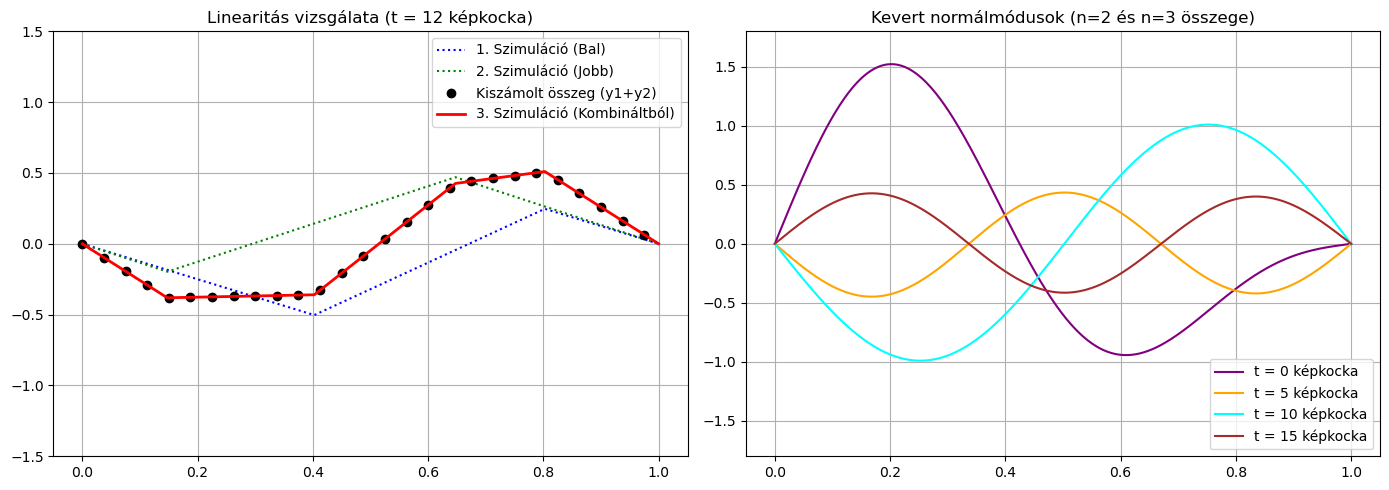

A legnagyobb elteres a ket oldal ( (y1+y2) es y_sum ) kozott: 1.00e-06
GIF animáció generálása folyamatban... (ez eltarthat egy percig)
GIF animáció sikeresen elmentve (task5_animacio.gif)!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

try:
    data_ic1 = np.loadtxt("datas/lin_ic1.data")
    data_ic2 = np.loadtxt("datas/lin_ic2.data")
    data_sum = np.loadtxt("datas/lin_sum.data")
    data_mixed = np.loadtxt("datas/mixed_modes.data")
except OSError:
    print("Hiba: Nem találhatók a .data fájlok.")
    exit()

N_frames = data_ic1.shape[0]
N_points = data_ic1.shape[1]
x = np.linspace(0, 1.0, N_points)

frame_static = 12
fig_static, ax_static = plt.subplots(1, 2, figsize = (14, 5))

ax_static[0].plot(x, data_ic1[frame_static], ":", color = "blue", label = "1. Szimuláció (Bal)")
ax_static[0].plot(x, data_ic2[frame_static], ":", color = "green", label = "2. Szimuláció (Jobb)")
ax_static[0].plot(x, data_ic1[frame_static] + data_ic2[frame_static], "o", color = "black", label = "Kiszámolt összeg (y1+y2)", markevery=15)
ax_static[0].plot(x, data_sum[frame_static], "-", color = "red", linewidth=2, label = "3. Szimuláció (Kombináltból)")

ax_static[0].set_title(f"Linearitás vizsgálata (t = {frame_static} képkocka)")
ax_static[0].set_ylim(-1.5, 1.5)
ax_static[0].grid(True)
ax_static[0].legend()

frames_to_plot = [0, 5, 10, 15]
colors = ["purple", "orange", "cyan", "brown"]
for i, f in enumerate(frames_to_plot):
    if f < N_frames:
        ax_static[1].plot(x, data_mixed[f], color = colors[i], label = f"t = {f} képkocka")

ax_static[1].set_title("Kevert normálmódusok (n=2 és n=3 összege)")
ax_static[1].set_ylim(-1.8, 1.8)
ax_static[1].grid(True)
ax_static[1].legend()

plt.tight_layout()
plt.savefig("task5_linearitas_es_modusok.pdf")
print("Statikus ábra elmentve (task5_linearitas_es_modusok.pdf)!")
plt.show()

max_hiba = np.max(np.abs((data_ic1 + data_ic2) - data_sum))
print(f"A legnagyobb elteres a ket oldal ( (y1+y2) es y_sum ) kozott: {max_hiba:.2e}")


fig_anim, ax_anim = plt.subplots(1, 2, figsize = (14, 5))

ax_anim[0].set_xlim(0, 1.0)
ax_anim[0].set_ylim(-1.5, 1.5)
ax_anim[0].grid(True)
line1_ic1, = ax_anim[0].plot([], [], ":", color = "blue", alpha = 0.6, label = "1. Szimuláció")
line1_ic2, = ax_anim[0].plot([], [], ":", color = "green", alpha = 0.6, label = "2. Szimuláció")
line1_calc_sum, = ax_anim[0].plot([], [], "o", color = "black", label = "Kiszámolt összeg", markevery = 15)
line1_sim_sum, = ax_anim[0].plot([], [], "-", color = "red", linewidth = 2, label = "3. Szimuláció (Kombinált)")
# ax_anim[0].legend(loc = "upper right", fontsize=10)

ax_anim[1].set_xlim(0, 1.0)
ax_anim[1].set_ylim(-1.8, 1.8)
ax_anim[1].grid(True)
line2_mixed, = ax_anim[1].plot([], [], color = "purple", linewidth = 2)

main_title = fig_anim.suptitle("Hullámegyenlet Linearitás és Interferenciája", fontsize = 16)

def init():
    line1_ic1.set_data([], [])
    line1_ic2.set_data([], [])
    line1_calc_sum.set_data([], [])
    line1_sim_sum.set_data([], [])
    line2_mixed.set_data([], [])
    return line1_ic1, line1_ic2, line1_calc_sum, line1_sim_sum, line2_mixed

def animate(i):
    line1_ic1.set_data(x, data_ic1[i, :])
    line1_ic2.set_data(x, data_ic2[i, :])
    line1_calc_sum.set_data(x, data_ic1[i, :] + data_ic2[i, :])
    line1_sim_sum.set_data(x, data_sum[i, :])
    ax_anim[0].set_title(f"Linearitás teszt (t = {i})")

    line2_mixed.set_data(x, data_mixed[i, :])
    ax_anim[1].set_title(f"Kevert normálmódusok (t = {i})")
    
    return line1_ic1, line1_ic2, line1_calc_sum, line1_sim_sum, line2_mixed

anim = animation.FuncAnimation(fig_anim, animate, init_func = init,
                               frames = N_frames, interval = 20, blit = True)

print("GIF animáció generálása folyamatban... (ez eltarthat egy percig)")
anim.save("task5_animacio.gif", writer = "pillow", fps = 25)
print("GIF animáció sikeresen elmentve (task5_animacio.gif)!")

plt.close(fig_anim)

Statikus ábra elmentve (surlodas_vizsgalat.pdf)!


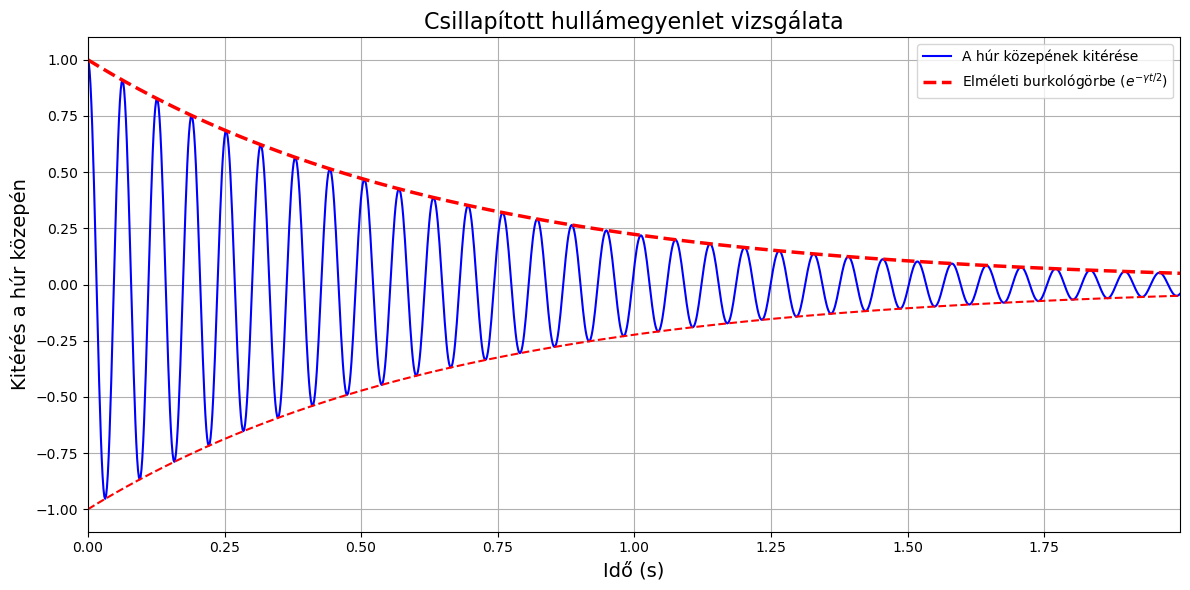

GIF animáció generálása folyamatban... (ez eltarthat fél percig)
GIF animáció sikeresen elmentve (surlodas_animacio.gif)!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

try:
    data = np.loadtxt("datas/string_friction.data")
except OSError:
    print("Hiba: Nem található a 'datas/string_friction.data' fájl. Futtasd előbb a C++ kódot!")
    exit()

N_frames = data.shape[0]
N_points = data.shape[1]

L = 1.0
c = np.sqrt(10.0 / 0.01)
gamma = 3.0

dx = L / (N_points - 1)
dt = 1.0 * (dx / c)
skip_frames = 20
dt_saved = skip_frames * dt

time = np.arange(N_frames) * dt_saved
x = np.linspace(0, L, N_points)

center_idx = N_points // 2
y_center = data[:, center_idx]

envelope_upper = np.exp(- (gamma / 2.0) * time)
envelope_lower = -np.exp(- (gamma / 2.0) * time)

plt.figure(figsize = (12, 6))

plt.plot(time, y_center, color = "blue", linewidth = 1.5, label = "A húr közepének kitérése")

plt.plot(time, envelope_upper, "r--", linewidth = 2.5, label = r"Elméleti burkológörbe ($e^{-\gamma t / 2}$)")
plt.plot(time, envelope_lower, "r--")

plt.title("Csillapított hullámegyenlet vizsgálata", fontsize = 16)
plt.xlabel("Idő (s)", fontsize = 14)
plt.ylabel("Kitérés a húr közepén", fontsize = 14)
plt.xlim(0, max(time))
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.legend(loc = "upper right")

plt.tight_layout()
plt.savefig("surlodas_vizsgalat.pdf")
print("Statikus ábra elmentve (surlodas_vizsgalat.pdf)!")
plt.show()


fig_anim, ax_anim = plt.subplots(figsize = (10, 5))

ax_anim.set_xlim(0, L)
ax_anim.set_ylim(-1.1, 1.1)
ax_anim.set_xlabel("Pozíció, x (m)", fontsize = 12)
ax_anim.set_ylabel("Kitérés, y (m)", fontsize = 12)
ax_anim.grid(True)

line, = ax_anim.plot([], [], color = "blue", linewidth = 2.5)

time_text = ax_anim.text(0.02, 0.95, "", transform = ax_anim.transAxes, fontsize = 12, fontweight = "bold")

def init():
    """Az animáció kezdeti állapota."""
    line.set_data([], [])
    time_text.set_text("")
    return line, time_text

def animate(i):
    """Az i-edik képkocka frissítése."""
    y_current = data[i, :]
    line.set_data(x, y_current)
    
    current_physical_time = time[i]
    time_text.set_text(f"Idő = {current_physical_time:.4f} s")
    ax_anim.set_title(f"Súrlódó húr rezgése (1. módus)")
    
    return line, time_text

print("GIF animáció generálása folyamatban... (ez eltarthat fél percig)")
anim = animation.FuncAnimation(fig_anim, animate, init_func = init,
                               frames = N_frames, interval = 25, blit = True)

anim.save("surlodas_animacio.gif", writer = "pillow", fps = 40)
print("GIF animáció sikeresen elmentve (surlodas_animacio.gif)!")

plt.close(fig_anim)